In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

In [3]:
tool.invoke("Langgraphのノードとは？")

[{'url': 'https://www.ibm.com/think/topics/langgraph',
  'content': 'Nodes: In LangGraph, nodes represent individual components or agents within an AI workflow. Nodes can be thought of as “actors” that interact with each other in a specific way. For example,to add nodes for tool calling, one can use the ToolNode. Another example, the next node, refers to the node that will be executed following the current one.'},
 {'url': 'https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141',
  'content': 'Stateful Graph: LangGraph revolves around the concept of a stateful graph, where each node in the graph represents a step in your computation, and the graph maintains a state that is passed around and updated as the computation progresses.\n Nodes: Nodes are the building blocks of your LangGraph. Each node represents a function or a computation step. You define nodes to perform specific tasks, such as processing input, making decisions, or interacting with external API

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]

# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

In [5]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition, # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

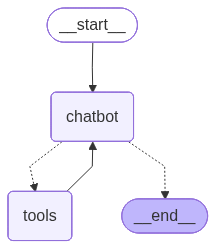

In [6]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは！
こんにちは！今日はどんなことをお手伝いできますか？
1足す2は？
1足す2は3です。何か他に知りたいことはありますか？
1メートル以上の魚は？

[{"url": "https://tsurihack.com/8448", "content": "大物釣りの魅力のひとつに、魚達の力強さを一本の釣り糸を通して体感できることがあります。 とくに1m、10kgを超えるような魚の重量感溢れるファイトで、身体が引っ張"}, {"url": "https://tsurihack.com/1870", "content": "LINE公式アカウント 最新の釣り情報をチェック！ 友だち追加はこちら\n![TSURI HACK[釣りハック]](\nMENU\n日本三大怪魚の画像\n\n# 日本三大怪魚とは？その種類と特徴、釣ることはできるのか！\n\n日本三大怪魚。1メートルを超える巨大な魚体と、希少さから釣り人から幻の魚ともよばれる3種。大型魚に魅了された怪魚ハンターの様に、釣ってみたいと考える方もいらっしゃるのではないでしょうか。今回、日本三大怪魚の各種をご紹介します。\n\n2023/06/20 更新\n\n本ページはアフィリエイトプログラムを利用しています。\n\nTSURI HACK編集部\n\n編集者\n\nTSURI HACK編集部\n\n釣り歴20年のTSURI HACK運営＆記事編集担当。年間1000を超える記事を配信するため、海から川・湖、エサ釣りからルアーまで幅広い釣り用品に触れています。公式SNSでも最新情報から編集部のインプレッションまで絶賛配信中！\n\nAngler@ライター\n\n制作者\n\nAngler@ライター [...] 渓流からバス釣り、シーバス、ロックフィッシュ、五目釣りからチヌのヘチ釣りまで、ジャンルを問わず関東地方のフィールドを釣り歩いています。子供の頃から大の釣り好き。今までの経験を元に釣りの楽しさや魅力を多くの人に伝えていきたいと思っています。よろしくお願いいたします。\n\n目次\n\n## 日本三大怪魚とは\n\nクエッションの画像\n\nクエッションの画像\n\n日本の限られた地域にのみ生息し、1メートルを超える大型に成長する「日本三大怪魚」。その稀少さと見た目から、国内では絶滅危惧類として指定される魚もいるほど